<a href="https://colab.research.google.com/github/mahaapoorani/Machine-Learning-Projects/blob/main/Decision_Tree_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
data= load_breast_cancer()
df= pd.DataFrame(data.data, columns= data.feature_names)
df["target"]= data.target

In [4]:
X= df.drop("target", axis=1)
y= df["target"]

In [9]:
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size= 0.2, random_state= 42)

In [6]:
model= DecisionTreeClassifier(random_state= 42)
model.fit (X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [7]:
y_pred= model.predict(X_test)

In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.9473684210526315

Confusion Matrix
[[40  3]
 [ 3 68]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [11]:
print("\nActual vs Predicted\n")

for actual, predicted in zip(y_test[:10], y_pred[:10]):
    print("ACTUAL:", actual)
    print("PREDICTED:", predicted)
    print("-" * 30)


Actual vs Predicted

ACTUAL: 1
PREDICTED: 1
------------------------------
ACTUAL: 0
PREDICTED: 0
------------------------------
ACTUAL: 0
PREDICTED: 0
------------------------------
ACTUAL: 1
PREDICTED: 1
------------------------------
ACTUAL: 1
PREDICTED: 1
------------------------------
ACTUAL: 0
PREDICTED: 0
------------------------------
ACTUAL: 0
PREDICTED: 0
------------------------------
ACTUAL: 0
PREDICTED: 0
------------------------------
ACTUAL: 1
PREDICTED: 0
------------------------------
ACTUAL: 1
PREDICTED: 1
------------------------------


In [12]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                    Feature  Importance
7       mean concave points    0.691420
27     worst concave points    0.065651
1              mean texture    0.058478
20             worst radius    0.052299
22          worst perimeter    0.051494
19  fractal dimension error    0.018554
21            worst texture    0.017445
17     concave points error    0.015931
13               area error    0.011983
24         worst smoothness    0.009233
16          concavity error    0.006276
14         smoothness error    0.001237
2            mean perimeter    0.000000
3                 mean area    0.000000
12          perimeter error    0.000000
11            texture error    0.000000
10             radius error    0.000000
9    mean fractal dimension    0.000000
6            mean concavity    0.000000
8             mean symmetry    0.000000
4           mean smoothness    0.000000
5          mean compactness    0.000000
0               mean radius    0.000000
15        compactness error    0.000000


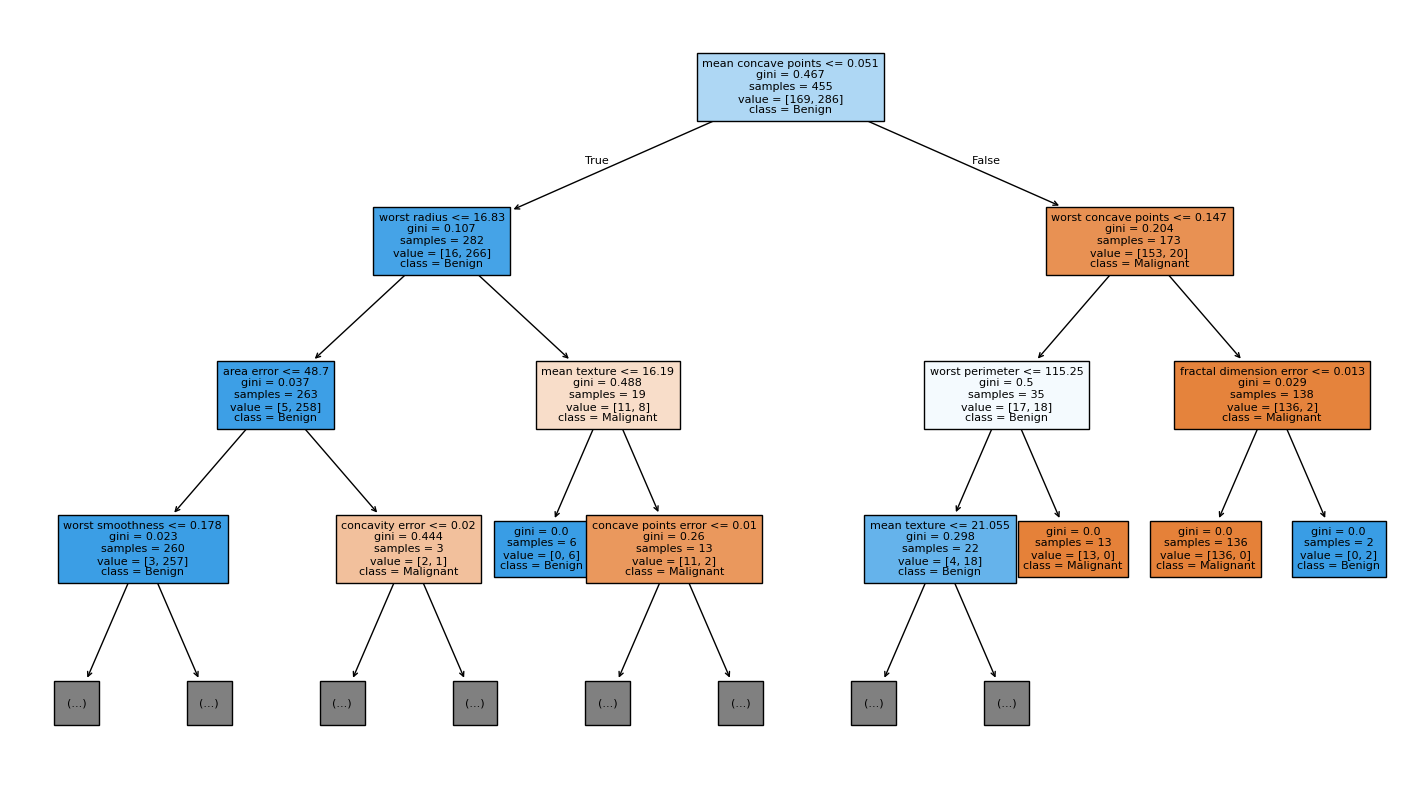

In [13]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))

plot_tree(
    model,
    filled=True,
    feature_names=X.columns,
    class_names=["Malignant", "Benign"],
    max_depth=3,
    fontsize=8
)

plt.show()

In [14]:
for depth in [2, 3, 4, 5, 6, 8, 10]:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"Max Depth = {depth}  Accuracy = {accuracy:.4f}")

Max Depth = 2  Accuracy = 0.9298
Max Depth = 3  Accuracy = 0.9474
Max Depth = 4  Accuracy = 0.9474
Max Depth = 5  Accuracy = 0.9474
Max Depth = 6  Accuracy = 0.9386
Max Depth = 8  Accuracy = 0.9474
Max Depth = 10  Accuracy = 0.9474
